In [5]:
import os
import random
import time  # <-- Import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA
from collections import defaultdict
from scipy.stats import wasserstein_distance

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 100,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "data-analysis/data",
    "hist_bins": 30,  # for 2D histogram
    "num_seeds": 3,   # Number of random seeds for repeated trials
    "kl_eps": 1e-12,  # Smoothing parameter for KL, JS, etc.
    "use_adaptive_gamma": True  # Whether to select gamma adaptively for MMD
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    """
    Simple 'drift' function that shuffles a fraction of words in each text.
    """
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# 1) Building Distribution Histograms in 2D
###############################################################################
def build_2d_hist(embs_2d, bins=30):
    """
    Given Nx2 embeddings, build a 2D histogram *as a probability distribution*.
    We turn off 'density=True', then manually normalize so that it sums to 1.
    """
    hist, xedges, yedges = np.histogram2d(
        embs_2d[:, 0],
        embs_2d[:, 1],
        bins=bins,
        density=False
    )
    # Normalize so sum of all bins = 1
    hist = hist / hist.sum()
    return hist, xedges, yedges

###############################################################################
# 2) Common Distribution-Based Distances or Divergences
###############################################################################
def safe_prob(p, eps=1e-12):
    """
    Utility to avoid zeros for logs or divisions.
    """
    return np.maximum(p, eps)

def kl_divergence(p, q, kl_eps=1e-12):
    """
    Discrete KL Divergence:
        KL(P||Q) = sum_i p_i * log( p_i / q_i )
    """
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    return np.sum(p_ * np.log(p_ / q_))

def js_divergence(p, q, kl_eps=1e-12):
    """
    Jensen-Shannon Divergence:
        JS(P||Q) = 0.5 * KL(P || M) + 0.5 * KL(Q || M)
        where M = 0.5*(P+Q)
    """
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    m_ = 0.5 * (p_ + q_)
    return 0.5 * kl_divergence(p_, m_, kl_eps=kl_eps) + 0.5 * kl_divergence(q_, m_, kl_eps=kl_eps)

def hellinger_distance(p, q, kl_eps=1e-12):
    """
    Hellinger distance for discrete distributions:
        H^2(P, Q) = 1 - sum_i sqrt(p_i * q_i)
        => H(P, Q) = sqrt( H^2(...) )
    """
    p_ = np.sqrt(safe_prob(p, eps=kl_eps))
    q_ = np.sqrt(safe_prob(q, eps=kl_eps))
    return np.sqrt(np.sum((p_ - q_)**2) / 2.0)

def bhattacharyya_distance(p, q, kl_eps=1e-12):
    """
    Bhattacharyya distance:
        d_B(P, Q) = -ln( sum_i sqrt(p_i q_i) )
    """
    bc = np.sum(np.sqrt(safe_prob(p, eps=kl_eps) * safe_prob(q, eps=kl_eps)))
    return -np.log(bc + 1e-12)  # Prevent log(0)


def compute_2d_hist_distance(baseline_embs, new_embs, measure="js",
                             bins=30, kl_eps=1e-12):
    """
    1) Build 2D histograms with the same bin edges
    2) Compute the specified measure
    """
    # Build histogram for baseline
    hist_p, xedges, yedges = build_2d_hist(baseline_embs, bins=bins)

    # Build histogram for new data using the *same* bin edges
    hist_q_raw, _, _ = np.histogram2d(
        new_embs[:, 0],
        new_embs[:, 1],
        bins=[xedges, yedges],
        density=False
    )
    # Normalize so that hist_q sums to 1 as well
    hist_q = hist_q_raw / hist_q_raw.sum()

    p = hist_p.flatten()
    q = hist_q.flatten()

    # Choose distance measure
    if measure == "kl":
        return kl_divergence(p, q, kl_eps=kl_eps)
    elif measure == "js":
        return js_divergence(p, q, kl_eps=kl_eps)
    elif measure == "hellinger":
        return hellinger_distance(p, q, kl_eps=kl_eps)
    elif measure == "bhattacharyya":
        return bhattacharyya_distance(p, q, kl_eps=kl_eps)
    else:
        raise ValueError(f"Unknown measure: {measure}")

###############################################################################
# 3) Simple MMD Computation (sample-based, no histogram)
###############################################################################
def rbf_kernel(x, y, gamma=1.0):
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2*np.dot(x, y.T)
    return np.exp(-gamma * dist2)

def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    """
    MMD^2 = E[k(x,x')] + E[k(y,y')] - 2 E[k(x,y)]
    Return sqrt(MMD^2).
    """
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m = len(X)
    n = len(Y)

    mmd2 = XX.sum() / (m**2) + YY.sum() / (n**2) - 2.0 * XY.sum() / (m*n)
    return np.sqrt(mmd2)

def auto_select_gamma(embs):
    """
    Simple heuristic: use gamma = 1/(2*median_of_pairwise_distance^2).
    """
    # Subsample if needed (for speed)
    sample = embs
    if len(embs) > 500:
        sample = embs[np.random.choice(len(embs), 500, replace=False)]
    dists = []
    for i in range(len(sample)-1):
        dist2 = np.sum((sample[i] - sample[i+1:])**2, axis=1)
        dists.append(dist2)
    dists = np.concatenate(dists)
    median_dist2 = np.median(dists)
    if median_dist2 <= 0.0:
        median_dist2 = 1e-6
    return 1.0 / (2.0 * median_dist2)

###############################################################################
# 4) Multi-D Wasserstein (Sum of 1D)
###############################################################################
def compute_wasserstein_1D_per_dim(baseline_embs, new_embs):
    d = baseline_embs.shape[1]
    w_sum = 0.0
    for i in range(d):
        w_sum += wasserstein_distance(baseline_embs[:, i], new_embs[:, i])
    return w_sum

###############################################################################
# 5) Main function for a single seed
###############################################################################
def run_experiment_single_seed(seed, args):
    # Set the random seed
    set_seed(seed)

    # Detect device
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        # We'll split the data in half: baseline vs. drift region
        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model.to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # Fit PCA on the baseline embeddings
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)
            baseline_embs_2d = pca.transform(baseline_embs)

            # If we are doing an adaptive gamma for MMD, compute it now
            if args["use_adaptive_gamma"]:
                gamma_val = auto_select_gamma(baseline_embs)
            else:
                gamma_val = 0.5

            distribution_measures = ["kl","js","hellinger",
                                     "bhattacharyya","mmd","wasserstein"]

            for measure_name in distribution_measures:
                for drift_strength in args["drift_strengths"]:

                    # 1) Start total timing
                    start_time = time.time()

                    # Create drifted text
                    drifted_texts = introduce_gradual_drift(drift_texts,
                                                            fraction_shuffle=drift_strength)
                    # Extract new embeddings
                    new_embs = []
                    for b in batch_generator(drifted_texts, args["batch_size"]):
                        emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                        new_embs.append(emb_b)
                    new_embs = np.concatenate(new_embs, axis=0)
                    new_embs_2d = pca.transform(new_embs)

                    # 2) Measure overhead timing
                    overhead_start = time.time()
                    if measure_name in ["kl", "js", "hellinger", "bhattacharyya"]:
                        dist_val = compute_2d_hist_distance(
                            baseline_embs_2d,
                            new_embs_2d,
                            measure=measure_name,
                            bins=args["hist_bins"],
                            kl_eps=args["kl_eps"]
                        )
                    elif measure_name == "mmd":
                        dist_val = compute_mmd(
                            baseline_embs,
                            new_embs,
                            gamma=gamma_val
                        )
                    elif measure_name == "wasserstein":
                        dist_val = compute_wasserstein_1D_per_dim(
                            baseline_embs_2d,
                            new_embs_2d
                        )
                    else:
                        dist_val = None
                    overhead_end = time.time()
                    measure_overhead = overhead_end - overhead_start

                    # 3) End total timing
                    end_time = time.time()
                    time_taken = end_time - start_time

                    # 4) Store detailed results
                    # Key will identify dataset, model, measure, drift_strength
                    key = (dataset_name, model_name, measure_name, drift_strength)

                    # We'll store a dict with (distance val, total time, measure overhead)
                    results[key].append({
                        "dist_val": dist_val,
                        "time_taken": time_taken,
                        "measure_overhead": measure_overhead,
                        "seed": seed
                    })

    return results

###############################################################################
# 6) Collect data across multiple seeds
###############################################################################
def collect_data_multiple_seeds(args):
    all_results = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results = run_experiment_single_seed(seed, args)
        # Merge seed_results into all_results
        for k, list_of_records in seed_results.items():
            all_results[k].extend(list_of_records)  # accumulate
    print("Data collection (all seeds) done!")
    return all_results

all_results = collect_data_multiple_seeds(args)

[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=1] Using device: mps
[Seed=1] === Loading dataset: yelp_review_full ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: wikitext ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: ag_news ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=2] Using device: mps
[Seed=2] === Loading dataset: yelp_review_full 

In [6]:
###############################################################################
# 7) Plot with Error Bars
###############################################################################
import math

def plot_distribution_distances(all_results, args):
    """
    We now have keys of the form:
       (dataset_name, model_name, measure_name, drift_strength) -> [dist_val_seed1, dist_val_seed2, ...]
    We'll group by dataset/model, then create subplots for each measure.
    """
    # Organize keys by (dataset_name, model_name)
    from collections import defaultdict
    plot_data = defaultdict(lambda: defaultdict(list))

    # Example: plot_data[(dataset_name, model_name)][measure_name] = list of (drift_strength, mean, std)
    for (dataset_name, model_name, measure_name, drift_strength), values in all_results.items():
        mean_val = np.mean(values)
        std_val  = np.std(values)
        plot_data[(dataset_name, model_name)][measure_name].append( (drift_strength, mean_val, std_val) )

    # Now we loop over each (dataset_name, model_name)
    for (dataset_name, model_name), measure_dict in plot_data.items():
        measure_names = sorted(measure_dict.keys())  # e.g. ['bhattacharyya','hellinger',...]
        n_measures = len(measure_names)

        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)

        fig, axs = plt.subplots(n_rows, n_cols,
                                figsize=(5 * n_cols, 4 * n_rows),
                                sharex=True)
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, measure_name in enumerate(measure_names):
            ax = axs[i]
            data_points = measure_dict[measure_name]
            # Sort by drift_strength
            data_points = sorted(data_points, key=lambda x: x[0])
            x_vals = [dp[0] for dp in data_points]
            y_means = [dp[1] for dp in data_points]
            y_stds  = [dp[2] for dp in data_points]

            ax.errorbar(x_vals, y_means, yerr=y_stds,
                        fmt='-o', capsize=3, label=f"{measure_name}")

            ax.set_title(measure_name, fontsize=10)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance / Divergence")
            ax.grid(True, linestyle='--', alpha=0.5)
            if i == 0:
                ax.legend()

        for j in range(i+1, n_rows*n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path)
        plt.show()
        print(f"Saved figure: {save_path}")

plot_distribution_distances(all_results, args)

TypeError: unsupported operand type(s) for +: 'dict' and 'dict'

In [3]:
import pandas as pd

# Convert defaultdict to a structured DataFrame
rows = []
for (dataset, model, measure, drift_strength), values in all_results.items():
    for value in values:
        rows.append([dataset, model, measure, drift_strength, value])

# Create DataFrame
df = pd.DataFrame(rows, columns=["Dataset", "Model", "Measure", "Drift Strength", "Value"])

# Group by Dataset, Model, Measure, and Drift Strength, then compute mean and std
df_aggregated = df.groupby(["Dataset", "Model", "Measure", "Drift Strength"]).agg(
    Mean_Value=("Value", "mean"),
    Std_Value=("Value", "std")
).reset_index()

# Save to CSV
save_path = os.path.join(args["output_dir"], "all_results_distribution_aggregated.csv")
df_aggregated.to_csv(save_path, index=False)

print(f"Saved aggregated data to: {save_path}")

df_aggregated


TypeError: agg function failed [how->mean,dtype->object]

In [16]:
# save all_results to csv
import pandas as pd

def save_results_to_csv(all_results, args):
    """
    Save the results to a CSV file for further analysis.
    """
    summary_data = []

    # Aggregate results across all datasets and models
    for (dataset_name, model_name, measure_name, drift_strength), values in all_results.items():
        mean_val = np.mean(values)
        std_val = np.std(values)
        summary_data.append((dataset_name, model_name, measure_name, drift_strength, mean_val, std_val))

    # Convert to Pandas DataFrame
    df = pd.DataFrame(summary_data, columns=["Dataset", "Model", "Measure", "Drift Strength", "Mean", "Std"])

    df.head()

    # Save to CSV for further analysis
    save_path = os.path.join(args["output_dir"], "all_results_distribution.csv")
    df.to_csv(save_path, index=False)
    print(f"Saved summary table to: {save_path}")


save_results_to_csv(all_results, args)

Saved summary table to: data-analysis/data/all_results_distribution.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def visualize_results(all_results):
    """
    Convert the 'all_results' dictionary to a DataFrame and create plots
    for dist_val, time_taken, and measure_overhead as a function of drift_strength.
    all_results is assumed to be a dict with keys:
        (dataset_name, model_name, measure_name, drift_strength)
    and values = list of dicts, each containing:
        {
            "dist_val": float,
            "time_taken": float,
            "measure_overhead": float,
            "seed": int
        }
    """

    # 1) Convert 'all_results' into a pandas DataFrame
    rows = []
    for (dataset, model, measure, drift_strength), records in all_results.items():
        for rec in records:
            rows.append({
                "dataset": dataset,
                "model": model,
                "measure": measure,
                "drift_strength": drift_strength,
                "dist_val": rec["dist_val"],
                "time_taken": rec["time_taken"],
                "measure_overhead": rec["measure_overhead"],
                "seed": rec["seed"]
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No results to visualize. DataFrame is empty.")
        return

    # 2) Group by dataset, model, measure, drift_strength
    #    and compute mean & std for dist_val, time_taken, measure_overhead
    grouped = (
        df.groupby(["dataset", "model", "measure", "drift_strength"])
        .agg(
            dist_val_mean=("dist_val", "mean"),
            dist_val_std=("dist_val", "std"),
            time_taken_mean=("time_taken", "mean"),
            time_taken_std=("time_taken", "std"),
            overhead_mean=("measure_overhead", "mean"),
            overhead_std=("measure_overhead", "std"),
        )
        .reset_index()
    )

    # 3) Create plots
    #    We'll create three types of plots per (dataset, model):
    #    one for dist_val, one for total time, and one for overhead,
    #    grouped by measure.

    datasets = grouped["dataset"].unique()
    models = grouped["model"].unique()

    for ds in datasets:
        for md in models:
            subset = grouped[(grouped["dataset"] == ds) & (grouped["model"] == md)]

            if subset.empty:
                continue

            measures = subset["measure"].unique()

            # A) Plot dist_val vs drift_strength
            plt.figure(figsize=(8, 5))
            for measure in measures:
                sub_m = subset[subset["measure"] == measure]
                # Sort by drift_strength in case it's not in order
                sub_m = sub_m.sort_values("drift_strength")

                plt.errorbar(
                    sub_m["drift_strength"],
                    sub_m["dist_val_mean"],
                    yerr=sub_m["dist_val_std"],
                    label=measure,
                    marker="o",
                    capsize=5,
                )
            plt.title(f"Distance vs. Drift Strength\nDataset={ds}, Model={md}")
            plt.xlabel("Drift Strength")
            plt.ylabel("Distance Value (mean ± std)")
            plt.grid(True)
            plt.legend()
            plt.show()

            # B) Plot time_taken vs drift_strength
            plt.figure(figsize=(8, 5))
            for measure in measures:
                sub_m = subset[subset["measure"] == measure].sort_values("drift_strength")
                plt.errorbar(
                    sub_m["drift_strength"],
                    sub_m["time_taken_mean"],
                    yerr=sub_m["time_taken_std"],
                    label=measure,
                    marker="o",
                    capsize=5,
                )
            plt.title(f"Total Time Taken vs. Drift Strength\nDataset={ds}, Model={md}")
            plt.xlabel("Drift Strength")
            plt.ylabel("Time Taken (mean ± std, seconds)")
            plt.grid(True)
            plt.legend()
            plt.show()

            # C) Plot measure_overhead vs drift_strength
            plt.figure(figsize=(8, 5))
            for measure in measures:
                sub_m = subset[subset["measure"] == measure].sort_values("drift_strength")
                plt.errorbar(
                    sub_m["drift_strength"],
                    sub_m["overhead_mean"],
                    yerr=sub_m["overhead_std"],
                    label=measure,
                    marker="o",
                    capsize=5,
                )
            plt.title(f"Measure Overhead vs. Drift Strength\nDataset={ds}, Model={md}")
            plt.xlabel("Drift Strength")
            plt.ylabel("Overhead (mean ± std, seconds)")
            plt.grid(True)
            plt.legend()
            plt.show()


# Example usage:
# After running your main script that populates 'all_results', call:
visualize_results(all_results)


NameError: name 'all_results' is not defined

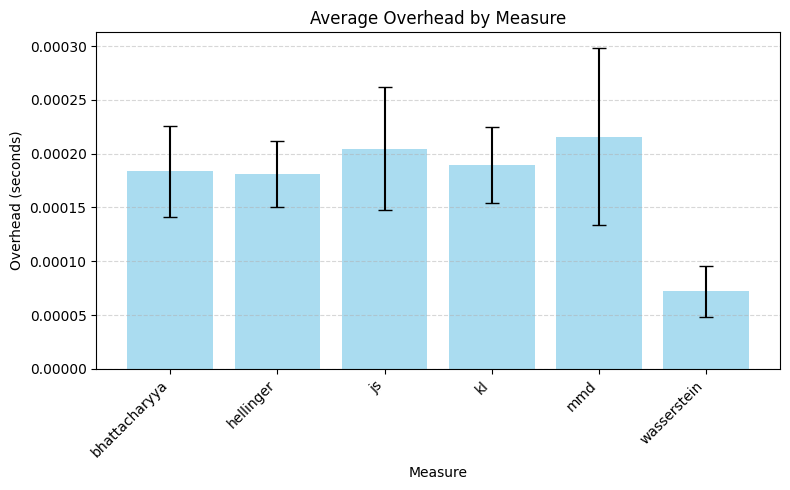

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def visualize_average_overhead_by_measure(all_results):
    """
    Collapse across datasets, models, and drift_strength,
    and produce a bar chart of average overhead per measure.
    """

    # 1) Convert 'all_results' into a pandas DataFrame
    rows = []
    for (dataset, model, measure, drift_strength), records in all_results.items():
        for rec in records:
            rows.append({
                "dataset": dataset,
                "model": model,
                "measure": measure,
                "drift_strength": drift_strength,
                "dist_val": rec["dist_val"],
                "time_taken": rec["time_taken"],
                "measure_overhead": rec["measure_overhead"],
                "seed": rec["seed"],
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No results to visualize. DataFrame is empty.")
        return

    # 2) Group by just 'measure' (ignore dataset/model/drift_strength)
    #    and compute mean & std for measure_overhead
    grouped = (
        df.groupby("measure")["measure_overhead"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "overhead_mean", "std": "overhead_std"})
    )

    # 3) Create a bar plot (with error bars) for overhead per measure
    plt.figure(figsize=(8, 5))

    # X positions for each measure on the bar chart
    x_positions = range(len(grouped))

    # Bar chart
    plt.bar(
        x_positions,
        grouped["overhead_mean"],
        yerr=grouped["overhead_std"],
        capsize=5,
        alpha=0.7,
        color="skyblue"
    )

    # Label the x-axis with measure names
    plt.xticks(ticks=x_positions, labels=grouped["measure"], rotation=45, ha="right")

    plt.title("Average Overhead by Measure")
    plt.xlabel("Measure")
    plt.ylabel("Overhead (seconds)")
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

visualize_average_overhead_by_measure(all_results)

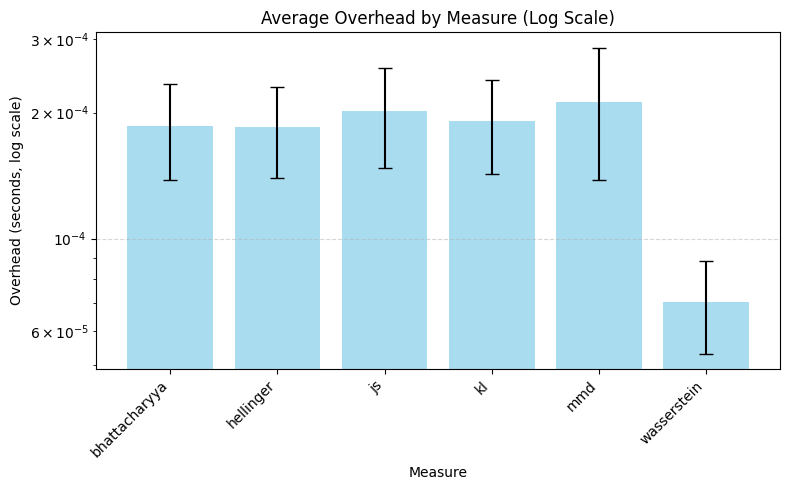

Saved results to: data-analysis/data-test/average_overhead_distribution.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def visualize_average_overhead_by_measure(all_results, output_csv_path):
    """
    Collapse across datasets, models, and drift_strength,
    and produce a bar chart of average overhead per measure (log scale).
    Save the results to a CSV file.
    """

    # 1) Convert 'all_results' into a pandas DataFrame
    rows = []
    for (dataset, model, measure, drift_strength), records in all_results.items():
        for rec in records:
            rows.append({
                "dataset": dataset,
                "model": model,
                "measure": measure,
                "drift_strength": drift_strength,
                "dist_val": rec["dist_val"],
                "time_taken": rec["time_taken"],
                "measure_overhead": rec["measure_overhead"],
                "seed": rec["seed"],
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No results to visualize. DataFrame is empty.")
        return

    # 2) Group by just 'measure' (ignore dataset/model/drift_strength)
    #    and compute mean & std for measure_overhead
    grouped = (
        df.groupby("measure")["measure_overhead"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "overhead_mean", "std": "overhead_std"})
    )

    # 3) Create a bar plot (with error bars) for overhead per measure
    plt.figure(figsize=(8, 5))

    # X positions for each measure on the bar chart
    x_positions = range(len(grouped))

    # Bar chart
    plt.bar(
        x_positions,
        grouped["overhead_mean"],
        yerr=grouped["overhead_std"],
        capsize=5,
        alpha=0.7,
        color="skyblue"
    )

    # Apply log scale
    plt.yscale("log")  # <-- LOG SCALE applied

    # Label the x-axis with measure names
    plt.xticks(ticks=x_positions, labels=grouped["measure"], rotation=45, ha="right")

    plt.title("Average Overhead by Measure (Log Scale)")
    plt.xlabel("Measure")
    plt.ylabel("Overhead (seconds, log scale)")
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

    # Save the grouped DataFrame to a CSV file
    grouped.to_csv(output_csv_path, index=False)
    print(f"Saved results to: {output_csv_path}")

    return grouped

# Example usage:
output_csv_path = "data-analysis/data-test/average_overhead_distribution.csv"
grouped_df = visualize_average_overhead_by_measure(all_results, output_csv_path)